# Sweeping a laser pointer across an infinite wall

## Scenario

A laser pointer sits at the origin. An infinite flat wall stands at $y = D$. The pointer sweeps in
the plane perpendicular to the wall at constant angular speed, counterclockwise, starting along the
$+x$ axis ($\alpha = 0$) and ending along the $-x$ axis ($\alpha = \pi$) after a $180°$ sweep, so

$$\alpha(t) = \omega t, \qquad \omega = \frac{\pi}{T} > 0 .$$

At both ends of the sweep the beam runs **parallel** to the wall and never meets it. In between, the
illuminated spot enters from $x = +\infty$, crosses to $x = 0$ at the closest approach, and leaves
towards $x = -\infty$.

This is the flat-target companion to `MoonSweep.ipynb`, which did the same sweep against a sphere.

## Why a plane, after a sphere

The Moon gave the physics but not the algebra: its ray–sphere intersection carries a square root,
so the fold, the slowest spot and the limb speed all had to be found numerically. A plane has no
square root, and the whole problem collapses onto a **single dimensionless number**

$$\mu = \frac{k\,D\,\omega}{c},$$

with $k$ the number of light-travel legs. Everything below is then a closed form in $\mu$ — obtained
from SymPy, not typed in by hand — and the numerics only ever *check* those closed forms.

## What this notebook derives

1. The path length $L(\alpha)$ and the spot position $x(\alpha)$ on the wall.
2. The **arrival time** $\tau(t) = t + kL/c$ of the light, and why it is not monotonic.
3. Closed forms, all in $\mu$: the fold $\cos\alpha^* = \tfrac{1}{2}\!\left(\sqrt{\mu^2+4}-\mu\right)$,
   the slowest spot at $\cos\alpha = -\mu/2$, the crossings of $|v| = c$, and the grazing limits.
4. The **image doubling**, which here never ends: past $\tau^*$ there are two spots for ever.
5. The **photon front**, which for a uniform sweep is exactly an Archimedean spiral, and whose
   tangency to the wall is a second, purely geometric route to $\alpha^*$.
6. A **regime map** in $\mu$, with its threshold at $\mu = 2$.

Two systems are run through the same machinery: a desk-scale laser pointer, and a wall placed on the
Moon's tangent plane and swept at `MoonSweep.ipynb`'s own rate, which reproduces that notebook's
$-1.153076\,c$ exactly.

## Conventions

Departure time $t \in (0, T)$ is the parameter for everything, exactly as in `MoonSweep.ipynb`:
one departure time labels one illumination event, so every quantity stays single-valued and the
doubling shows up as a non-monotonic $\tau(t)$.

Here $\omega > 0$ (the Moon notebook had $\omega < 0$), but the meaning of the sign of $v$ is
unchanged: **$v < 0$ means the spot runs with the sweep**, $v > 0$ is the backward-running spot.

## 1. Symbolic setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO
from IPython.display import SVG, display
from sympy import *

init_printing()

# Geometry and dynamics
c     = symbols('c', positive=True)      # speed of light
D     = symbols('D', positive=True)      # laser-to-wall distance (the wall is the plane y = D)
T     = symbols('T', positive=True)      # sweep duration
omega = symbols('omega', positive=True)  # sweep rate; the sweep runs alpha = 0 -> pi
L     = symbols('L', positive=True)      # flight path length, laser to wall
x, y  = symbols('x y')                   # coordinates of the illuminated point
alpha = symbols('alpha')                 # aim angle, measured from the +x axis
t     = symbols('t')                     # departure time of the photon

# The reduction
k     = symbols('k', positive=True)      # number of light-travel legs (kept symbolic where possible)
mu    = symbols('mu', positive=True)     # mu = k*D*omega/c -- the only parameter that matters
u     = symbols('u')                     # u = cos(alpha), no assumptions: roots are filtered by physics

### 1.1 Where the beam meets the wall

The beam leaves the origin at angle $\alpha$ and travels a distance $L$, so the illuminated point is
$(L\cos\alpha,\; L\sin\alpha)$; it is on the wall when its $y$ coordinate equals $D$. That is three
equations in $L, x, y$, and `solve` returns the intersection rather than it being written down.

Unlike the sphere, this system is linear in the unknowns: there is exactly one solution, no root has
to be selected, and no square root appears anywhere.

In [2]:
geometry = solve([y - D, x - L*cos(alpha), y - L*sin(alpha)], L, x, y, dict=True)
assert len(geometry) == 1, f'expected a single intersection, got {len(geometry)}'
(hit,) = geometry

pathLength   = Lambda(alpha, hit[L])   # L(alpha)
spotPosition = Lambda(alpha, hit[x])   # x(alpha)

pathLength(alpha), spotPosition(alpha)

In [3]:
# Sanity checks on the closed forms
assert simplify(pathLength(pi/2) - D) == 0                                     # closest approach
assert simplify(spotPosition(pi/2)) == 0                                       # ... is at x = 0
assert simplify(pathLength(alpha)*sin(alpha) - D) == 0                         # the point is on the wall
assert simplify(spotPosition(alpha)**2 + D**2 - pathLength(alpha)**2) == 0     # Pythagoras
print('verified: L*sin(alpha) = D, x^2 + D^2 = L^2, and L(pi/2) = D at x = 0')

verified: L*sin(alpha) = D, x^2 + D^2 = L^2, and L(pi/2) = D at x = 0


### 1.2 Sweep dynamics

The sweep runs from $\alpha = 0$ to $\alpha = \pi$ over a duration $T$, so $\omega = \pi/T$.

Both endpoints are **grazing**: the beam lies in a plane parallel to the wall and the intersection
runs off to infinity. So the domain of departure times is the *open* interval $(0, T)$ — the first
structural difference from the Moon, whose sweep had two well-defined limbs.

In [4]:
alphaStart, alphaEnd = Integer(0), pi

sweepAngle   = Lambda(t, alphaStart + omega*t)      # aim direction vs departure time
angularSpeed = (alphaEnd - alphaStart)/T            # rad per unit time

sweepAngle(t), angularSpeed

## 2. Arrival time

A photon leaving at departure time $t$ covers the path $L(\alpha(t))$ and lands at

$$\tau(t) \;=\; t + \frac{k\,L(\alpha(t))}{c}$$

with $k = 1$ for the light arriving at the wall and $k = 2$ for the scattered light seen back at the
laser. As in `MoonSweep.ipynb`, everything downstream is parameterised by $k$, so both observers cost
one extra call — and here $k$ can be kept **symbolic** all the way through the derivation.

In [5]:
def makeArrivalTime(legs):
    '''Arrival time as a function of departure time t, for `legs` light-travel legs.'''
    return Lambda(t, t + legs*pathLength(sweepAngle(t))/c)

def makePointSpeed(legs):
    '''Speed of the illuminated spot along the wall, as a function of departure time t.

    v = dx/dtau = (dx/dt)/(dtau/dt), using that dt/dtau is the derivative of the inverse
    of tau(t) and therefore equals 1/(dtau/dt).
    '''
    return Lambda(t, diff(spotPosition(sweepAngle(t)), t)/diff(makeArrivalTime(legs)(t), t))

makeArrivalTime(k)(t)

## 3. The reduction to one parameter

Written in terms of the aim angle $\alpha$ rather than the time, both $d\tau/dt$ and the spot speed
depend on the system only through

$$\mu \;=\; \frac{k\,D\,\omega}{c}.$$

$\mu$ is the transverse speed of the aim point at closest approach, in units of $c$, times the leg
count. Every closed form below is a function of $\mu$ alone — which is why one notebook covers a
laser pointer on a bedroom wall and a wall at the distance of the Moon.

The reductions are *asserted*, not assumed: SymPy checks that the substituted forms are identical.

In [6]:
muDef   = k*D*omega/c                               # the definition
atAlpha = lambda e: simplify(e.subs(t, alpha/omega))  # re-express a function of t as a function of alpha

arrivalRate = atAlpha(diff(makeArrivalTime(k)(t), t))            # dtau/dt
pointSpeed  = atAlpha(makePointSpeed(k)(t))                      # v

arrivalRateReduced = 1 - mu*cos(alpha)/sin(alpha)**2
pointSpeedReduced  = -c*mu/(k*(sin(alpha)**2 - mu*cos(alpha)))

assert simplify(arrivalRate - arrivalRateReduced.subs(mu, muDef)) == 0
assert simplify(pointSpeed  - pointSpeedReduced.subs(mu, muDef)) == 0
print('dtau/dt =', arrivalRateReduced)
print('v       =', pointSpeedReduced)

dtau/dt = -mu*cos(alpha)/sin(alpha)**2 + 1
v       = -c*mu/(k*(-mu*cos(alpha) + sin(alpha)**2))


Both share the denominator $\sin^2\alpha - \mu\cos\alpha$. Since it only ever involves
$\cos\alpha$ once $\sin^2\alpha$ is written as $1 - \cos^2\alpha$, it is a **quadratic in
$u = \cos\alpha$** — and that single fact is the source of every closed form in this notebook.

In [7]:
# den(alpha) = sin^2(alpha) - mu*cos(alpha) = denPoly(cos(alpha))
denPoly = Lambda(u, 1 - u**2 - mu*u)

assert simplify(denPoly(cos(alpha)) - (sin(alpha)**2 - mu*cos(alpha))) == 0
denPoly(u)

### 3.1 The fold: where the pair of images is created

$d\tau/dt = 0$ is $\sin^2\alpha = \mu\cos\alpha$, i.e. $\operatorname{denPoly}(u) = 0$. Of the two
roots exactly one is a cosine; it is selected by that **physical condition**, never by list index.

In [8]:
foldRoots = solve(Eq(denPoly(u), 0), u)
probe     = {mu: Rational(1, 2)}                          # any mu > 0 will do to test admissibility
physical  = [r for r in foldRoots if Abs(r.subs(probe)) <= 1]
assert len(physical) == 1, f'expected one admissible root, got {foldRoots}'
cosFold = simplify(physical[0])

# The discriminant mu^2 + 4 is positive for every mu, and the root lies in (0, 1):
# a fold always exists, and always before the closest approach.
assert limit(cosFold, mu, 0, '+') == 1 and limit(cosFold, mu, oo) == 0
cosFold

$\cos\alpha^* \in (0, 1)$ for every $\mu > 0$, so **the fold always exists** and always lies on the
half of the sweep the beam started from. However slowly the pointer is turned, the far wings of the
wall are far enough away that their light is overtaken: image doubling is not a high-speed effect
here, it is unconditional.

### 3.2 The slowest spot, and the threshold at $\mu = 2$

$|v| = c\mu / (k\,|\!\operatorname{den}|)$, so the spot is slowest where the denominator is largest.
Differentiating in $\alpha$ factorises, and the factor $\sin\alpha$ only vanishes at the two grazing
ends — the poles, not interior extrema. The interior extremum is the other factor.

In [9]:
denDeriv = factor(diff(denPoly(cos(alpha)), alpha))       # = sin(alpha)*(2*cos(alpha) + mu)
print('d(den)/dalpha =', denDeriv)

(cosSlow,) = solve(Eq(2*cos(alpha) + mu, 0), cos(alpha))  # sin(alpha) = 0 is the grazing pole
denSlow    = simplify(denPoly(cosSlow))
speedSlow  = simplify((c*mu/k)/denSlow)

print('cos(alpha_slow) =', cosSlow, '    den there =', denSlow)
print('|v|min          =', speedSlow)

d(den)/dalpha = (mu + 2*cos(alpha))*sin(alpha)
cos(alpha_slow) = -mu/2     den there = mu**2/4 + 1
|v|min          = 4*c*mu/(k*(mu**2 + 4))


$\cos\alpha_{slow} = -\mu/2$ is only a cosine while $\mu \le 2$. That is the notebook's **threshold**:

- $\mu \le 2$ — the spot decelerates to a genuine interior minimum
  $|v|_{min} = \dfrac{4c\mu}{k\,(4+\mu^2)}$, then speeds back up.
- $\mu > 2$ — there is no interior minimum at all. The denominator is monotonic, and $|v|$ falls
  towards $c/k$ without ever getting there.

For $k = 1$ the minimum is $4\mu/(4+\mu^2)$ in units of $c$, which is $\le 1$ with equality **only**
at $\mu = 2$. So the spot on the wall always slows to at most $c$, and $\mu = 2$ is exactly the
sweep rate at which it grazes $c$ once instead of dropping below it.

In [10]:
# |v|min/c = 4*mu/(4 + mu^2) <= 1 for k = 1, with equality only at mu = 2
gap = simplify(1 - (speedSlow/c).subs(k, 1))
print('1 - |v|min/c =', factor(gap), '  -> a square, so >= 0, and zero only at mu = 2')
assert factor(gap) == (mu - 2)**2/(mu**2 + 4)

1 - |v|min/c = (mu - 2)**2/(mu**2 + 4)   -> a square, so >= 0, and zero only at mu = 2


### 3.3 The grazing limits: exactly $c/k$

At both ends of the sweep the beam runs parallel to the wall. Unlike the Moon notebook — where
`limit()` did not terminate in reasonable time and the limb speed had to be demonstrated numerically
with exact rationals — here the limits come straight out of SymPy, **with $k$ still symbolic**.

In [11]:
entry = limit(pointSpeedReduced/c, alpha, 0,  '+')
exit_ = limit(pointSpeedReduced/c, alpha, pi, '-')
print(f'alpha -> 0+   :  v/c -> {entry}')
print(f'alpha -> pi-  :  v/c -> {exit_}')
assert entry == 1/k and exit_ == -1/k

alpha -> 0+   :  v/c -> 1/k
alpha -> pi-  :  v/c -> -1/k


So the spot enters at $+c/k$ and leaves at $-c/k$, for **every** $k$, every distance and every sweep
rate. This is the same result as the Moon's limb speed, and it is the same mechanism: at grazing
incidence the surface displacement of the spot is parallel to the ray, so the path length changes at
exactly the rate the spot moves, and the light-delay compression saturates. The Moon reached grazing
incidence at a tangency on its limb; the wall reaches it asymptotically at $x = \pm\infty$.

### 3.4 Closest approach: the leg count cancels

At $\alpha = \pi/2$ the path length is at its minimum, so $dL/dt = 0$ and $k$ drops out exactly.
Both observers measure the same speed there — a free check that $k$ is threaded correctly.

In [12]:
closest = simplify(pointSpeedReduced.subs(mu, muDef).subs(alpha, pi/2))
print('v at closest approach =', closest, '  -- no k, no c')
assert closest == -D*omega and k not in closest.free_symbols

v at closest approach = -D*omega   -- no k, no c


### 3.5 Where the spot is seen to move at exactly $c$

$|v| = c$ means $|\!\operatorname{den}| = \mu/k$, so the crossings are the roots of two more
quadratics in $u = \cos\alpha$ — one for each branch, since the denominator is negative before the
fold and positive after it.

In [13]:
def lightSpeedCrossings(muValue, legs):
    '''cos(alpha) where |v| = c, as closed forms; returns (backward branch, forward branch).

    mu is substituted as an exact Rational, so |u| < 1 is decided exactly. That matters:
    at k = 1 the boundary roots are exactly u = -+1, and a float would land one ulp inside.
    '''
    exact = {mu: Rational(muValue), k: Integer(legs)}
    out = []
    for sign in (-1, +1):                       # den < 0 before the fold, den > 0 after it
        roots = [r.subs(exact) for r in solve(Eq(denPoly(u) - sign*mu/k, 0), u)]
        # admissible cosines only; the open domain (0, pi) excludes the grazing ends u = -+1
        out.append(sorted(float(r) for r in roots if Abs(r) < 1))
    return out

# For k = 1 the boundary roots are exactly u = -+1: the grazing asymptotes themselves.
for sign, atEnd in ((+1, -1), (-1, +1)):
    assert simplify((denPoly(u) - sign*mu/k).subs({u: atEnd, k: 1})) == 0
print('k = 1: u = -+1 solve |v| = c exactly -- the grazing ends approach c without crossing it')

k = 1: u = -+1 solve |v| = c exactly -- the grazing ends approach c without crossing it


## 4. Systems: the scale is a parameter

`MoonSweep.ipynb` hard-wired one set of constants. Here the scale is an argument, because the whole
problem depends on it only through $\nu = D\omega/c$ — so one class covers every wall.

The same substitution trap applies: $\omega$ must be resolved to a **number once**, before it goes
into the substitution dictionary. Putting `{T: ..., omega: pi/T}` in one dict does not work, because
SymPy substitutes simultaneously and the `T` introduced by `omega` survives the pass.

In [14]:
def bisect(f, lo, hi, tol=1e-15, maxIter=300):
    '''Root of f on a bracket [lo, hi] where f changes sign.'''
    flo, fhi = f(lo), f(hi)
    if not flo*fhi < 0:
        raise ValueError(f'no sign change on [{lo}, {hi}]: f = {flo}, {fhi}')
    for _ in range(maxIter):
        if hi - lo < tol:
            break
        mid = 0.5*(lo + hi)
        if flo*f(mid) <= 0:
            hi = mid
        else:
            lo, flo = mid, f(mid)
    return 0.5*(lo + hi)

def signChanges(f, lo, hi, samples=20001):
    '''All roots of f on [lo, hi], located by scanning for sign changes then refining.'''
    xs = np.linspace(lo, hi, samples)
    with np.errstate(all='ignore'):
        ys = np.array([f(v) for v in xs], dtype=float)
    return [bisect(f, xs[i], xs[i+1]) for i in range(len(xs) - 1)
            if np.isfinite(ys[i]) and np.isfinite(ys[i+1]) and ys[i]*ys[i+1] < 0]

def minimise(f, lo, hi, tol=1e-13, maxIter=800):
    '''Interior minimum of a unimodal f on [lo, hi], by golden-section search.'''
    invPhi = (np.sqrt(5) - 1)/2
    x1, x2 = hi - invPhi*(hi - lo), lo + invPhi*(hi - lo)
    f1, f2 = f(x1), f(x2)
    for _ in range(maxIter):
        if hi - lo < tol:
            break
        if f1 < f2:
            hi, x2, f2 = x2, x1, f1
            x1 = hi - invPhi*(hi - lo); f1 = f(x1)
        else:
            lo, x1, f1 = x1, x2, f2
            x2 = lo + invPhi*(hi - lo); f2 = f(x2)
    return 0.5*(lo + hi)

In [15]:
class WallSystem:
    '''One physical scale: wall distance, sweep rate, speed of light, and the units they are in.

    Give either the sweep duration or the sweep rate; the other follows from omega = pi/T.
    '''

    def __init__(self, label, distance, speedOfLight, lengthUnit, timeUnit,
                 sweepDuration=None, sweepRate=None):
        assert (sweepDuration is None) != (sweepRate is None), 'give exactly one of duration, rate'
        # Resolve omega to a number ONCE: {T: ..., omega: pi/T} in a single dict would leave
        # the T inside omega standing, because SymPy substitutes simultaneously.
        if sweepRate is None:
            sweepRate = float(angularSpeed.subs(T, sweepDuration))
        else:
            sweepRate, sweepDuration = float(sweepRate), float(pi/sweepRate)

        self.label = label
        self.lengthUnit, self.timeUnit = lengthUnit, timeUnit
        self.D, self.c = float(distance), float(speedOfLight)
        self.omega, self.T = sweepRate, sweepDuration
        self.values = {D: self.D, c: self.c, omega: self.omega}   # one flat dict, fully resolved
        self.nu = self.D*self.omega/self.c                        # mu at k = 1

        # Geometric invariants, checked after substitution
        assert abs(float(pathLength(pi/2).subs(self.values)) - self.D) < 1e-9*self.D
        assert abs(float(spotPosition(pi/2).subs(self.values))) < 1e-9*self.D

    def lengthsIn(self):
        return f'{self.lengthUnit}'

    def describe(self):
        return (f'{self.label}\n'
                f'    D = {self.D:g} {self.lengthUnit},  T = {self.T:g} {self.timeUnit},  '
                f'c = {self.c:g} {self.lengthUnit}/{self.timeUnit}\n'
                f'    omega = {self.omega:.9g} rad/{self.timeUnit}  ->  '
                f'nu = D*omega/c = {self.nu:.6f}   (mu = k*nu)')

The two systems. The first is a laser pointer on a wall three metres away, swept through $180°$ in
60 nanoseconds — a real scene with an absurd sweep rate, which is the point.

The second puts the wall on the **Moon's tangent plane at the sub-Earth point**, at $D - R$, and
sweeps it at `MoonSweep.ipynb`'s own rate $\omega = 2\arcsin(R/D)/T$. Near the middle of its sweep
the Moon *is* that tangent plane, so the two notebooks must agree there; §8.1 checks that they do.

In [16]:
desk = WallSystem('a wall 3 m away, swept in 60 ns', distance=3.0, speedOfLight=0.3,
                  lengthUnit='m', timeUnit='ns', sweepDuration=60.0)

# MoonSweep.ipynb's own geometry and sweep rate, rebuilt rather than copied
moonRadius, earthMoonDistance, moonSweepDuration = Rational(3475, 2), Integer(382500), Rational(1, 100)
moonSweepRate = float(2*asin(moonRadius/earthMoonDistance)/moonSweepDuration)

moonWall = WallSystem('a wall on the Moon tangent plane, at the MoonSweep rate',
                      distance=float(earthMoonDistance - moonRadius), speedOfLight=300000.0,
                      lengthUnit='km', timeUnit='s', sweepRate=moonSweepRate)

for system in (desk, moonWall):
    print(system.describe())
    print()

a wall 3 m away, swept in 60 ns
    D = 3 m,  T = 60 ns,  c = 0.3 m/ns
    omega = 0.0523598776 rad/ns  ->  nu = D*omega/c = 0.523599   (mu = k*nu)

a wall on the Moon tangent plane, at the MoonSweep rate
    D = 380762 km,  T = 3.458 s,  c = 300000 km/s
    omega = 0.908499856 rad/s  ->  nu = D*omega/c = 1.153076   (mu = k*nu)



### 4.1 The geometry, drawn

Everything so far is one picture. The beam leaves the origin at aim angle $\alpha$, runs a distance
$L(\alpha) = D/\sin\alpha$, and meets the wall at $x(\alpha) = D\cot\alpha$.

| symbol | meaning |
|---|---|
| $\alpha = \omega t$ | aim angle, from the $+x$ axis; the sweep runs $0 \to \pi$ |
| $L(\alpha) = D/\sin\alpha$ | path length, minimal ($=D$) at closest approach, $\to\infty$ at both ends |
| $x(\alpha) = D\cot\alpha$ | spot position along the wall, $+\infty \to -\infty$ |
| $\alpha^*$ | the fold: where the pair of images is created |

Every point below is placed with `pathLength` and `spotPosition` at the drawing's own $D$, and the
invariants are re-asserted on the drawing itself. Drawn at $\mu = \nu = 0.5236$, the desk system.

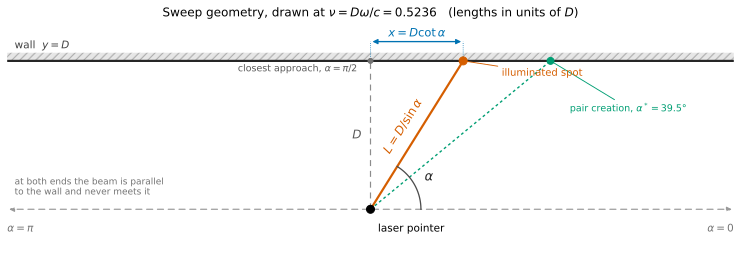

In [17]:
def drawGeometry(nuValue=None, figsize=(10.4, 4.4)):
    '''The sweep geometry as labelled line art. Lengths are in units of D.'''
    drawValues = {D: 1.0}
    reach   = lambda a: float(pathLength(a).subs(drawValues))       # L(alpha)
    onWall  = lambda a: float(spotPosition(a).subs(drawValues))     # x(alpha)
    nuValue = desk.nu if nuValue is None else nuValue
    alphaShown = float(np.radians(58.0))
    alphaFold  = float(acos(cosFold.subs(mu, nuValue)))
    spotX, foldX = onWall(alphaShown), onWall(alphaFold)
    span, wallTop, measure = 2.45, 1.055, 1.13

    fig, ax = plt.subplots(figsize=figsize)

    # the wall, hatched on its far side
    ax.plot([-span, span], [1, 1], color='0.15', lw=2.2, zorder=3)
    ax.fill_between([-span, span], 1, wallTop, color='0.90', hatch='///',
                    edgecolor='0.66', lw=0, zorder=1)
    ax.text(-span + 0.05, wallTop + 0.03, 'wall  $y = D$', fontsize=10.5, color='0.25')

    # the two grazing directions -- the start and the end of the sweep
    for direction, name, ha in ((+1, r'$\alpha = 0$', 'right'), (-1, r'$\alpha = \pi$', 'left')):
        ax.annotate('', xy=(direction*span, 0), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='-|>', color='0.60', lw=1.2, ls=(0, (5, 4))))
        ax.text(direction*span, -0.15, name, fontsize=10.5, color='0.45', ha=ha)
    ax.text(-span + 0.05, 0.10, 'at both ends the beam is parallel\n'
                                'to the wall and never meets it', fontsize=9, color='0.45')

    # closest approach
    ax.plot([0, 0], [0, 1], color='0.55', lw=1.2, ls=(0, (5, 4)), zorder=2)
    ax.text(-0.06, 0.50, '$D$', fontsize=12, color='0.35', ha='right', va='center')
    ax.plot([0], [1], 'o', color='0.45', ms=5, zorder=4)
    ax.text(-0.09, 0.93, r'closest approach, $\alpha = \pi/2$', fontsize=9.5,
            color='0.35', ha='right')

    # the fold ray
    ax.plot([0, foldX], [0, 1], color='#009E73', lw=1.4, ls=(0, (2, 2)), zorder=3)
    ax.plot([foldX], [1], 'o', color='#009E73', ms=7, zorder=5)
    ax.annotate(rf'pair creation, $\alpha^* = {np.degrees(alphaFold):.1f}\degree$',
                xy=(foldX, 1.0), xytext=(foldX + 0.13, 0.66), fontsize=9.5, color='#009E73',
                arrowprops=dict(arrowstyle='-', color='#009E73', lw=0.9, shrinkB=3))

    # the general ray, with L labelled along it
    ax.plot([0, spotX], [0, 1], color='#D55E00', lw=2.2, zorder=4)
    ax.plot([spotX], [1], 'o', color='#D55E00', ms=8, zorder=6)
    normal = np.array([-1.0, spotX])/np.hypot(1.0, spotX)          # perpendicular to the ray
    label  = np.array([0.5*spotX, 0.5]) + 0.11*normal
    ax.text(*label, r'$L = D/\sin\alpha$', fontsize=12, color='#D55E00', ha='center',
            va='center', rotation=np.degrees(np.arctan2(1, spotX)), rotation_mode='anchor')
    ax.annotate('illuminated spot', xy=(spotX, 1.0), xytext=(spotX + 0.26, 0.90),
                fontsize=10, color='#D55E00',
                arrowprops=dict(arrowstyle='-', color='#D55E00', lw=0.9, shrinkB=4))

    # x, measured along the wall from the foot of the perpendicular
    for edge in (0.0, spotX):
        ax.plot([edge, edge], [1.0, measure], color='#0072B2', lw=0.8, ls=':', zorder=2)
    ax.annotate('', xy=(spotX, measure), xytext=(0, measure),
                arrowprops=dict(arrowstyle='<|-|>', color='#0072B2', lw=1.3))
    ax.text(0.5*spotX, measure + 0.035, r'$x = D\cot\alpha$', fontsize=11.5,
            color='#0072B2', ha='center')

    # the aim angle
    arc = np.linspace(0, alphaShown, 96)
    ax.plot(0.34*np.cos(arc), 0.34*np.sin(arc), color='0.30', lw=1.3, zorder=4)
    ax.text(0.45*np.cos(0.5*alphaShown), 0.45*np.sin(0.5*alphaShown), r'$\alpha$',
            fontsize=13, color='0.15', ha='center', va='center')

    ax.plot([0], [0], 'o', color='k', ms=8, zorder=6)
    ax.text(0.05, -0.15, 'laser pointer', fontsize=10.5)

    # invariants asserted on the drawing itself
    for a in (alphaShown, alphaFold, float(np.radians(122.0))):
        assert abs(reach(a)*np.sin(a) - 1.0) < 1e-12          # the point is on the wall
        assert abs(onWall(a) - 1.0/np.tan(a)) < 1e-12         # x = D cot(alpha)
    assert abs(np.sin(alphaFold)**2 - nuValue*np.cos(alphaFold)) < 1e-12   # the fold condition

    ax.set_xlim(-span, span)
    ax.set_ylim(-0.30, 1.26)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(rf'Sweep geometry, drawn at $\nu = D\omega/c = {nuValue:.4f}$   '
                 r'(lengths in units of $D$)', fontsize=12)
    fig.tight_layout()
    return fig

def asSVG(figure):
    '''Render a Matplotlib figure as inline SVG, so line art stays sharp at any zoom.'''
    drawing = StringIO()
    figure.savefig(drawing, format='svg', bbox_inches='tight')
    plt.close(figure)
    return SVG(drawing.getvalue())

display(asSVG(drawGeometry()))

### 4.2 Path length and spot position against the aim angle

Both diverge at the two grazing ends, so the domain is drawn open. Note how much of the wall is
covered in how little of the sweep: half the sweep angle, from $45°$ to $135°$, covers only
$|x| \le D$, while the first and last few degrees cover everything else out to infinity.

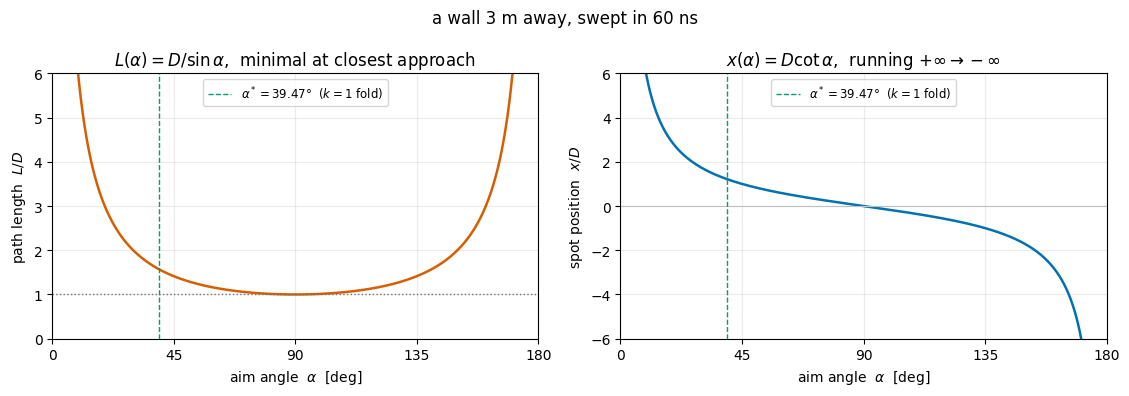

In [18]:
def plotAgainstAlpha(system, xClip=6.0):
    reach  = lambdify(alpha, pathLength(alpha).subs(system.values), 'numpy')
    onWall = lambdify(alpha, spotPosition(alpha).subs(system.values), 'numpy')
    a = np.linspace(0, np.pi, 4001)[1:-1]
    foldAt = np.degrees(float(acos(cosFold.subs(mu, system.nu))))   # the k = 1 fold

    fig, (axL, axX) = plt.subplots(1, 2, figsize=(11.4, 4.0))
    axL.plot(np.degrees(a), reach(a)/system.D, color='#D55E00', lw=1.8)
    axL.axhline(1, ls=':', lw=1, color='0.45')
    axL.set_ylim(0, 6)
    axL.set_ylabel('path length  $L/D$')
    axL.set_title(r'$L(\alpha) = D/\sin\alpha$,  minimal at closest approach')

    axX.plot(np.degrees(a), onWall(a)/system.D, color='#0072B2', lw=1.8)
    axX.axhline(0, lw=0.8, color='0.75')
    axX.set_ylim(-xClip, xClip)
    axX.set_ylabel('spot position  $x/D$')
    axX.set_title(r'$x(\alpha) = D\cot\alpha$,  running $+\infty \to -\infty$')

    for ax in (axL, axX):
        ax.axvline(foldAt, ls='--', lw=1, color='#009E73',
                   label=rf'$\alpha^* = {foldAt:.2f}\degree$  ($k = 1$ fold)')
        ax.legend(fontsize=8.5, loc='upper center')
        ax.set_xlabel(r'aim angle  $\alpha$  [deg]')
        ax.set_xlim(0, 180)
        ax.set_xticks([0, 45, 90, 135, 180])
        ax.grid(alpha=0.25)
    fig.suptitle(f'{system.label}', fontsize=12)
    fig.tight_layout()
    return fig

plotAgainstAlpha(desk)
plt.show()

## 5. The two spots, and the speed of each

### 5.1 Why departure time is the right parameter

Past the fold there are two illuminated spots, so there are two speeds. That looks like it needs two
functions, but it does not — provided the **departure time $t$** is the parameter.

Every photon leaving at time $t$ produces exactly one illumination event: it lands at $x(t)$ at
arrival time $\tau(t)$. One $t$, one event, always. So $x(t)$, $\tau(t)$ and $v(t)$ are all
single-valued. The doubling appears because $\tau$ is **not monotonic** in $t$: two departure times
share one arrival time. Observables must therefore be drawn *parametrically* in $t$ and split into
branches at the fold.

Here $\tau \to +\infty$ at both ends of the open domain and has a single interior minimum at $t^*$.
That has a consequence the Moon did not have:

> For every $\tau > \tau^*$ there are **exactly two** spots. The doubling window opens at $\tau^*$
> and **never closes**.

On the Moon the backward-running spot died when it reached the limb. Here there is no limb: it runs
out along the wall towards $x = +\infty$ for ever, while the forward spot runs to $x = -\infty$.

### 5.2 One case, one class

`WallCase` is the `SweepCase` of this notebook, but parameterised over the *system* as well as over
$k$. The closed forms of §3 supply every event; the bracketed root-finders are used only to **check**
them, never to produce them.

In [19]:
class WallCase:
    '''The sweep on one system, seen through k light-travel legs.

    k = 1: light arriving at the wall.   k = 2: scattered light seen back at the laser.
    '''

    def __init__(self, system, legs, label):
        self.system, self.k, self.label = system, legs, label
        values  = system.values
        tauExpr = makeArrivalTime(legs)(t).subs(values)

        self.tau  = lambdify(t, tauExpr, 'numpy')
        self.x    = lambdify(t, spotPosition(sweepAngle(t)).subs(values), 'numpy')
        self.v    = lambdify(t, makePointSpeed(legs)(t).subs(values), 'numpy')
        self.dtau = lambdify(t, diff(tauExpr, t), 'numpy')

        self.mu         = legs*system.nu
        self.grazing    = system.c/legs                       # |v| at both grazing ends
        self.grazeLabel = 'c' if legs == 1 else f'c/{legs}'
        self.tauLabel   = r'\tau = t + L/c' if legs == 1 else rf'\tau_{{obs}} = t + {legs}L/c'
        eps = 1e-12*system.T

        # --- the fold, from the closed form; the bracket only confirms it
        self.alphaStar = float(acos(cosFold.subs(mu, self.mu)))
        self.tStar     = self.alphaStar/system.omega
        assert abs(self.tStar - bisect(self.dtau, eps, system.T - eps)) < 1e-12*system.T
        self.tauStar, self.xStar = self.tau(self.tStar), self.x(self.tStar)

        # --- the slowest spot exists only while |cos(alpha_slow)| = mu/2 <= 1
        if self.mu <= 2:
            self.alphaSlow = float(acos(cosSlow.subs(mu, self.mu)))
            self.tSlow     = self.alphaSlow/system.omega
            self.vSlow     = float(speedSlow.subs({mu: self.mu, c: system.c, k: legs}))
            # Golden-section locates a quadratic minimum to about sqrt(eps) in t, so the
            # position is checked loosely and the speed -- which is what matters -- tightly.
            found = minimise(lambda s: abs(self.v(s)), self.tStar + eps, system.T - eps)
            assert abs(self.tSlow - found) < 1e-6*system.T
            assert abs(self.vSlow - abs(self.v(self.tSlow))) < 1e-12*self.vSlow
        else:
            self.alphaSlow = self.tSlow = self.vSlow = None

        # --- |v| = c, from the closed forms of 3.5, confirmed by scanning
        backward, forward = lightSpeedCrossings(self.mu, legs)
        self.cCross = ([('backward', float(np.arccos(w))) for w in backward]
                       + [('forward', float(np.arccos(w))) for w in forward])
        self.cCross.sort(key=lambda pair: pair[1])
        scanned = signChanges(lambda s: abs(self.v(s)) - system.c,
                              self.timeAt(np.radians(0.05)), self.timeAt(np.pi - np.radians(0.05)))
        assert len(scanned) == len(self.cCross), f'{len(scanned)} scanned vs {len(self.cCross)} closed-form'
        for (_, a), s in zip(self.cCross, sorted(scanned)):
            assert abs(a - self.alphaAt(s)) < 1e-9

    # --- conversions between the aim angle and the departure time
    def timeAt(self, a):   return a/self.system.omega
    def alphaAt(self, s):  return self.system.omega*s

    def timeForPosition(self, position):
        '''Departure time at which the spot sits at x = position (exact: alpha = arccot(x/D)).'''
        return self.timeAt(float(np.arctan2(self.system.D, position)))

    def summary(self):
        S, deg = self.system, np.degrees
        print(f'--- {self.label} — {S.label}   (k = {self.k}, mu = {self.mu:.6f}) ---')
        print(f'  pair creation      : alpha* = {deg(self.alphaStar):8.4f} deg,  '
              f't* = {self.tStar:.5f} {S.timeUnit}  (t*/T = {self.tStar/S.T:.4f})')
        print(f'                       tau* = {self.tauStar:.6f} {S.timeUnit},  '
              f'x* = {self.xStar:.6g} {S.lengthUnit} = {self.xStar/S.D:.4f} D')
        print(f'  doubling window    : tau > tau*, and it never closes -- two spots for ever')
        print(f'  grazing ends       : v -> +-{self.grazing:.6g} {S.lengthUnit}/{S.timeUnit} '
              f'= +-{self.grazeLabel}, at x = +-infinity')
        print(f'  closest approach   : v = {self.v(S.T/2)/S.c:.6f} c   (independent of k)')
        if self.vSlow is None:
            print(f'  slowest spot       : none -- mu > 2, so |v| falls towards '
                  f'{self.grazeLabel} without a minimum')
        else:
            print(f'  slowest spot       : |v| = {self.vSlow/S.c:.6f} c at '
                  f'alpha = {deg(self.alphaSlow):.4f} deg, x = {self.x(self.tSlow)/S.D:+.4f} D')
        for branch, a in self.cCross:
            print(f'  |v| = c            : {branch:8s} branch, alpha = {deg(a):8.4f} deg, '
                  f'x = {self.x(self.timeAt(a))/S.D:+.4f} D')

atWall = WallCase(desk, 1, 'Arrival at the wall')
atWall.summary()

--- Arrival at the wall — a wall 3 m away, swept in 60 ns   (k = 1, mu = 0.523599) ---
  pair creation      : alpha* =  39.4750 deg,  t* = 13.15833 ns  (t*/T = 0.2193)
                       tau* = 28.887998 ns,  x* = 3.64253 m = 1.2142 D
  doubling window    : tau > tau*, and it never closes -- two spots for ever
  grazing ends       : v -> +-0.3 m/ns = +-c, at x = +-infinity
  closest approach   : v = -0.523599 c   (independent of k)
  slowest spot       : |v| = 0.490014 c at alpha = 105.1769 deg, x = -0.2713 D
  |v| = c            : forward  branch, alpha =  61.5494 deg, x = +0.5418 D


### 5.3 The fold, plotted

$v$ is not a function of $\tau$, so the curve is drawn parametrically in the departure time and split
at $t^*$ into its two branches:

- **backward-running spot** ($t < t^*$): $d\tau/dt < 0$, so as arrival time advances the departure
  time runs *backwards*. This spot heads towards $x = +\infty$, back the way the sweep came.
- **forward spot** ($t > t^*$): moves with the sweep, towards $x = -\infty$.

They are born together at $t^*$ with infinite apparent speed and opposite directions. The wall is
infinite, so both branches are clipped at $|x| = 5D$ for drawing; they continue for ever.

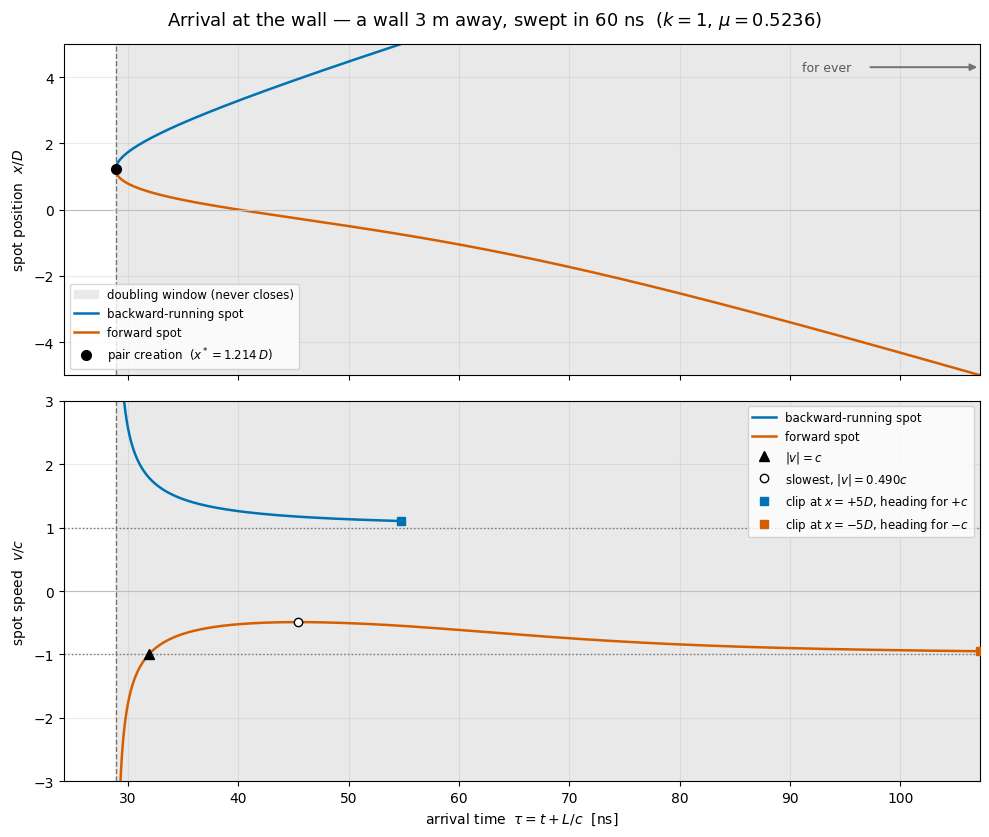

In [20]:
BACKWARD, FORWARD = '#0072B2', '#D55E00'   # colourblind-safe pair

def branchGrid(lo, hi, n=3000, eps=1e-12):
    '''Grid on the open interval (lo, hi), clustered at both ends where derivatives diverge.'''
    half = 0.5*(hi - lo)
    return np.unique(np.concatenate([lo + np.geomspace(eps*half, half, n),
                                     hi - np.geomspace(eps*half, half, n)]))

def evaluate(case, ts):
    '''tau, x/D and v/c on ts, with non-finite samples dropped.'''
    with np.errstate(all='ignore'):
        tau = np.asarray(case.tau(ts), dtype=float)
        pos = np.asarray(case.x(ts), dtype=float)/case.system.D
        vel = np.asarray(case.v(ts), dtype=float)/case.system.c
    good = np.isfinite(tau) & np.isfinite(pos) & np.isfinite(vel)
    return tau[good], pos[good], vel[good]

def plotCase(case, xClip=5.0, vlim=3.0, tauLim=None, title=None):
    S = case.system
    # The clip is exact: x = +-xClip*D at alpha = arccot(+-xClip).
    tLo, tHi = case.timeForPosition(xClip*S.D), case.timeForPosition(-xClip*S.D)
    branches = [('backward-running spot', BACKWARD, branchGrid(tLo, case.tStar)),
                ('forward spot',          FORWARD,  branchGrid(case.tStar, tHi))]
    tauRight = max(case.tau(tLo), case.tau(tHi))

    fig, (axX, axV) = plt.subplots(2, 1, figsize=(10, 8.5), sharex=True,
                                   gridspec_kw={'height_ratios': [1, 1.15]})
    for ax in (axX, axV):
        ax.axvspan(case.tauStar, tauRight, color='0.915', zorder=0,
                   label='doubling window (never closes)' if ax is axX else None)
        ax.axvline(case.tauStar, ls='--', lw=1, color='0.45', zorder=1)

    for name, colour, ts in branches:
        tau, pos, vel = evaluate(case, ts)
        axX.plot(tau, pos, color=colour, lw=1.8, label=name)
        axV.plot(tau, vel, color=colour, lw=1.8, label=name)

    for level in (1, -1):
        axV.axhline(level, ls=':', lw=1, color='0.45')
    axV.axhline(0, lw=0.8, color='0.75')
    if case.k != 1:
        for level in (case.grazing/S.c, -case.grazing/S.c):
            axV.axhline(level, ls='-.', lw=1, color='0.6')

    axX.plot([case.tauStar], [case.xStar/S.D], 'o', color='k', ms=7, zorder=5,
             label=f'pair creation  ($x^* = {case.xStar/S.D:.3f}\\,D$)')
    axX.axhline(0, lw=0.8, color='0.75')
    for n, (branch, a) in enumerate(case.cCross):
        s = case.timeAt(a)
        axV.plot([case.tau(s)], [case.v(s)/S.c], '^', color='k', ms=7, zorder=5,
                 label='$|v| = c$' if n == 0 else None)
    if case.tSlow is not None:
        axV.plot([case.tau(case.tSlow)], [case.v(case.tSlow)/S.c], 'o', color='k', ms=6,
                 mfc='white', zorder=5, label=f'slowest, $|v| = {case.vSlow/S.c:.3f}c$')
    for colour, s, side in ((BACKWARD, tLo, '+'), (FORWARD, tHi, '-')):
        axV.plot([case.tau(s)], [case.v(s)/S.c], 's', color=colour, ms=6, zorder=5,
                 label=f'clip at $x = {side}{xClip:g}D$, heading for ${side}{case.grazeLabel}$')

    axX.annotate('', xy=(tauRight, 0.86*xClip), xytext=(tauRight - 0.13*(tauRight - case.tauStar),
                 0.86*xClip), arrowprops=dict(arrowstyle='-|>', color='0.45', lw=1.4))
    axX.text(tauRight - 0.14*(tauRight - case.tauStar), 0.86*xClip, 'for ever  ',
             fontsize=9, color='0.35', ha='right', va='center')
    axX.set_ylabel(f'spot position  $x/D$')
    axX.set_ylim(-xClip, xClip)
    axV.set_ylabel('spot speed  $v/c$')
    axV.set_ylim(-vlim, vlim)
    axV.set_xlabel(f'arrival time  ${case.tauLabel}$  [{S.timeUnit}]')
    axV.set_xlim(*(tauLim or (case.tauStar - 0.06*(tauRight - case.tauStar), tauRight)))
    for ax, where in ((axX, 'lower left'), (axV, 'upper right')):
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8.5, loc=where)
    fig.suptitle(title or f'{case.label} — {S.label}  ($k = {case.k}$, $\\mu = {case.mu:.4f}$)',
                 fontsize=13)
    fig.tight_layout()
    return fig

plotCase(atWall)
plt.show()

The upper panel is the doubling: past $\tau^*$ a vertical line crosses the curve **twice**, so two
spots share one arrival time — and unlike the Moon's, the shaded region has no right-hand edge. The
lower panel gives each spot its speed.

Reading the story in arrival-time order:

1. Before $\tau^*$ the wall is completely dark. Light has been leaving the laser since $t = 0$, but
   the first rays were nearly parallel to the wall and are still in flight.
2. At $\tau^*$ the first light lands, at $x^* = 1.214\,D$, with **infinite** apparent speed.
3. The pair runs apart. The backward spot heads out to $+\infty$, decelerating towards $c$; the
   forward spot heads to $-\infty$, decelerating to $0.490\,c$ before speeding back up towards $c$.
4. Nothing ever annihilates them. Two spots, for ever.

## 6. What the observer at the laser sees

Everything above is light *landing* on the wall, $\tau = t + L/c$. That is the frame-independent
"when does the light arrive" question, but not what anyone watching sees. The scattered light has to
come back; for an observer beside the laser the round trip gives $\tau_{obs} = t + 2L/c$, the $k = 2$
case the machinery was written for. Only the leg count changes.

In [21]:
seenAtLaser = WallCase(desk, 2, 'Observed back at the laser')
seenAtLaser.summary()

--- Observed back at the laser — a wall 3 m away, swept in 60 ns   (k = 2, mu = 1.047198) ---
  pair creation      : alpha* =  52.7578 deg,  t* = 17.58592 ns  (t*/T = 0.2931)
                       tau* = 42.708898 ns,  x* = 2.28061 m = 0.7602 D
  doubling window    : tau > tau*, and it never closes -- two spots for ever
  grazing ends       : v -> +-0.15 m/ns = +-c/2, at x = +-infinity
  closest approach   : v = -0.523599 c   (independent of k)
  slowest spot       : |v| = 0.410938 c at alpha = 121.5740 deg, x = -0.6146 D
  |v| = c            : backward branch, alpha =  35.1940 deg, x = +1.4179 D
  |v| = c            : forward  branch, alpha =  69.9556 deg, x = +0.3648 D


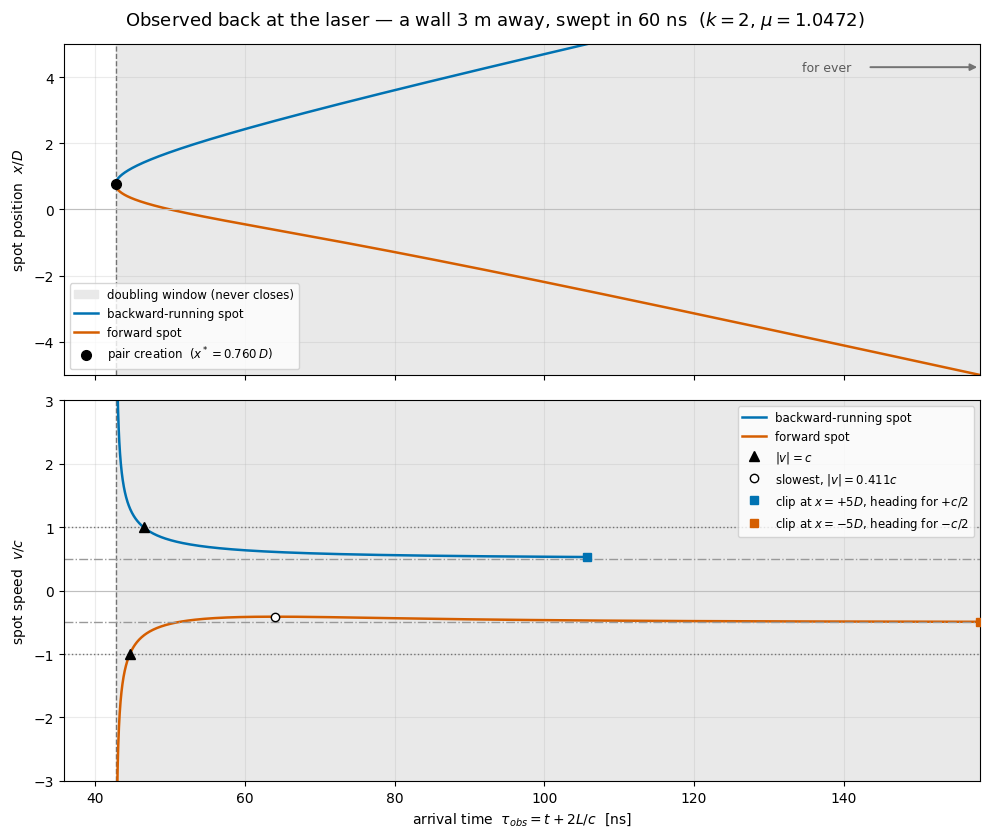

In [22]:
plotCase(seenAtLaser)
plt.show()

### 6.1 Surface arrival vs. observed

In [23]:
def comparisonTable(cases, system):
    fmt = lambda value, spec: '—' if value is None else format(value, spec)
    rows = [('mu = k*D*omega/c',                  lambda p: f'{p.mu:.6f}'),
            ('pair creation  alpha* [deg]',       lambda p: f'{np.degrees(p.alphaStar):.4f}'),
            (f'pair creation  t* [{system.timeUnit}]', lambda p: f'{p.tStar:.5f}'),
            ('pair creation  t*/T',               lambda p: f'{p.tStar/system.T:.4f}'),
            (f'pair creation  tau* [{system.timeUnit}]', lambda p: f'{p.tauStar:.6f}'),
            ('pair creation  x*/D',               lambda p: f'{p.xStar/system.D:.4f}'),
            ('speed at the grazing ends [c]',     lambda p: f'{p.grazing/system.c:.4f}'),
            ('slowest spot speed [c]',            lambda p: fmt(p.vSlow and p.vSlow/system.c, '.6f')),
            ('slowest at alpha [deg]',            lambda p: fmt(p.alphaSlow and np.degrees(p.alphaSlow), '.4f')),
            ('speed at closest approach [c]',     lambda p: f'{p.v(system.T/2)/system.c:.6f}'),
            ('number of |v| = c crossings',       lambda p: f'{len(p.cCross)}')]
    width = max(len(name) for name, _ in rows)
    heads = [f'k={p.k}' for p in cases]
    print(f'{system.label}   (nu = {system.nu:.6f})')
    print(f'{"":{width}}   ' + '   '.join(f'{h:>16}' for h in heads))
    print('-'*(width + 3 + 19*len(cases)))
    for name, get in rows:
        print(f'{name:{width}}   ' + '   '.join(f'{get(p):>16}' for p in cases))

comparisonTable([atWall, seenAtLaser], desk)

a wall 3 m away, swept in 60 ns   (nu = 0.523599)
                                             k=1                k=2
----------------------------------------------------------------------
mu = k*D*omega/c                        0.523599           1.047198
pair creation  alpha* [deg]              39.4750            52.7578
pair creation  t* [ns]                  13.15833           17.58592
pair creation  t*/T                       0.2193             0.2931
pair creation  tau* [ns]               28.887998          42.708898
pair creation  x*/D                       1.2142             0.7602
speed at the grazing ends [c]             1.0000             0.5000
slowest spot speed [c]                  0.490014           0.410938
slowest at alpha [deg]                  105.1769           121.5740
speed at closest approach [c]          -0.523599          -0.523599
number of |v| = c crossings                    1                  2


Three things to pull out of that table.

**The grazing speed halves, from $c$ to $c/2$.** The apparent speed of a spot is not a property of
the spot alone; it depends on where you stand. The light reporting the spot's position has its own
travel time, and a second leg doubles the delay compression.

**The speed at closest approach does not change at all.** At $\alpha = \pi/2$ the path length is
minimal, so $dL/dt = 0$ and $k$ cancels exactly out of $v = u/(1 + (k/c)\,dL/dt)$. At that one point
the observer and the wall agree.

**The observed spot crosses $c$ on the way in as well as on the way out.** For $k = 1$ the backward
spot is superluminal over its whole life, approaching $c$ from above; for $k = 2$ it *enters* at
$c/2$, accelerates through $c$, and becomes infinite at the fold. The extra leg turns one crossing
into two.

### 6.2 Cross-check of the derivation

The compact form $v = u/(1 + (k/c)\,dL/dt)$, with $u = dx/dt$ the geometric aim-point speed, was
derived by a different route than the chain rule used inside `makePointSpeed`. Asserting that the two
agree numerically validates the reasoning — the denominator is the light-delay compression factor,
the same $1/(1 - \beta\cos\theta)$ that makes astrophysical jets look superluminal.

In [24]:
for system in (desk, moonWall):
    aimSpeed = lambdify(t, diff(spotPosition(sweepAngle(t)), t).subs(system.values), 'numpy')   # u
    pathRate = lambdify(t, diff(pathLength(sweepAngle(t)), t).subs(system.values), 'numpy')     # dL/dt
    ts = np.linspace(0, system.T, 999)[1:-1]
    for legs in (1, 2):
        speedOf   = lambdify(t, makePointSpeed(legs)(t).subs(system.values), 'numpy')
        predicted = aimSpeed(ts)/(1 + (legs/system.c)*pathRate(ts))
        actual    = speedOf(ts)
        deviation = np.max(np.abs(predicted - actual)/np.maximum(np.abs(actual), system.c))
        assert deviation < 1e-10, deviation   # near the fold both forms diverge, so digits cancel
        print(f'{system.lengthUnit:>2}/{system.timeUnit:<2}  k = {legs}: '
              f'max relative deviation over {ts.size} samples = {deviation:.2e}   OK')

# u itself is unbounded at the grazing ends; the doubling comes from the line-of-sight component.
aimSpeed = lambdify(t, diff(spotPosition(sweepAngle(t)), t).subs(desk.values), 'numpy')
print(f'\naim-point speed u at closest approach = {aimSpeed(desk.T/2)/desk.c:.6f} c')
print(f'aim-point speed u near the grazing end = {aimSpeed(1e-6)/desk.c:.4g} c')

 m/ns  k = 1: max relative deviation over 997 samples = 1.39e-12   OK
 m/ns  k = 2: max relative deviation over 997 samples = 5.12e-14   OK
km/s   k = 1: max relative deviation over 997 samples = 1.87e-14   OK
km/s   k = 2: max relative deviation over 997 samples = 1.42e-14   OK

aim-point speed u at closest approach = -0.523599 c
aim-point speed u near the grazing end = -1.91e+14 c


## 7. The photon front is an Archimedean spiral

Sections 5 and 6 follow the illumination one departure time at a time, and the doubling shows up only
as a fold in a parametric curve. Here is the same physics as a picture in space.

The sweep does not emit one photon, it emits a **string** of them. The photon that left at $t$ runs
along the aim direction $\alpha(t) = \omega t$, and by wall-clock time $\tau$ it has covered
$c(\tau - t)$. Eliminating $t = \alpha/\omega$, the string at time $\tau$ is the curve

$$r(\alpha) \;=\; c\left(\tau - \frac{\alpha}{\omega}\right),$$

which is $r$ **linear in $\alpha$**: an Archimedean spiral, exactly. Not approximately, not for small
angles — a uniform angular sweep of light *is* an Archimedean spiral, of radial pitch $2\pi c/\omega
= 2cT$ per turn, unwinding outwards at $c$.

This is where the flat target pays again. `MoonSweep.ipynb` had to argue that its front was "a
straight chord to within 0.16 %" because the Moon subtends only $0.52°$; across a $180°$ sweep no
such approximation is available, and none is needed.

In [25]:
tau = symbols('tau', positive=True)
frontRadius = Lambda(alpha, c*(tau - alpha/omega))          # r(alpha) at wall-clock time tau

# Archimedean: r is linear in alpha, so its second derivative vanishes identically.
assert diff(frontRadius(alpha), alpha, 2) == 0
print('r(alpha)            =', frontRadius(alpha))
print('radial pitch / turn =', simplify(frontRadius(alpha) - frontRadius(alpha + 2*pi)))

r(alpha)            = c*(-alpha/omega + tau)
radial pitch / turn = 2*pi*c/omega


### 7.1 The tangency is the fold

The illuminated spots are where the spiral meets the wall, $r(\alpha)\sin\alpha = D$. The number of
spots is the number of solutions, so **pair creation is a double root** — the instant the spiral stops
missing the wall and grazes it.

Eliminating $\tau$ between the intersection condition and its derivative gives a condition on
$\alpha$ alone. It is $\sin^2\alpha = \nu\cos\alpha$: the $k = 1$ fold of §3.1, identically. Not
"agrees to $10^{-11}$" — the difference `simplify`s to zero.

In [26]:
frontHeight = frontRadius(alpha)*sin(alpha)                 # y coordinate of the front
tauOnWall   = solve(Eq(frontHeight, D), tau)[0]             # tau at which the front reaches the wall
tangency    = simplify(diff(frontHeight, alpha).subs(tau, tauOnWall))

# clear the denominator, then compare with the k = 1 fold condition sin^2(alpha) = nu*cos(alpha)
tangencyCleared = simplify(expand_trig(tangency*omega*sin(alpha)/c))
foldCondition   = sin(alpha)**2 - (D*omega/c)*cos(alpha)

print('tangency condition :', tangencyCleared, ' = 0')
print('k = 1 fold         :', -foldCondition, ' = 0')
assert simplify(tangencyCleared + foldCondition) == 0
print('\nidentical -- the spiral grazes the wall exactly at the pair-creation angle')

tangency condition : D*omega*cos(alpha)/c - sin(alpha)**2  = 0
k = 1 fold         : D*omega*cos(alpha)/c - sin(alpha)**2  = 0

identical -- the spiral grazes the wall exactly at the pair-creation angle


So the notebook has two independent routes to $\alpha^*$: the calculus one ($d\tau/dt = 0$, a
stationary arrival time) and the geometric one (a spiral tangent to a plane). They are the same
equation. The doubling is not an artefact of the algebra — it is what any smooth curve does when it
stops missing a surface: it touches once, then cuts twice.

### 7.2 The front, drawn

In [27]:
class SpiralCase:
    '''The photon front of one system, drawn in space, and the spots it makes on the wall.'''

    def __init__(self, system, label):
        self.system, self.label = system, label
        self.arrival = WallCase(system, 1, 'front')          # the front is a k = 1 object
        self.tStar, self.tauStar = self.arrival.tStar, self.arrival.tauStar
        self.reach = lambdify(t, pathLength(sweepAngle(t)).subs(system.values), 'numpy')

    def front(self, when, n=1400):
        '''The photon string at wall-clock time `when`, as (x, y, landed).

        A photon has landed once it has flown its own path length; those are frozen on the
        wall and make up the lit trail. The rest are still in flight and make up the spiral.
        '''
        S = self.system
        ts = np.linspace(0, min(when, S.T), n + 2)[1:-1]     # open: the ends are the poles
        with np.errstate(all='ignore'):
            flown, reach = S.c*(when - ts), self.reach(ts)
            landed = flown >= reach                          # L is +inf at the poles: never
            radius = np.where(landed, reach, flown)
        a = S.omega*ts
        return radius*np.cos(a), radius*np.sin(a), landed

    def spots(self, when):
        '''Departure times of the photons landing at wall-clock time `when`: 0, 1 or 2 of them.'''
        S, case = self.system, self.arrival
        if when < self.tauStar - 1e-12*self.tauStar:
            return []
        if abs(when - self.tauStar) <= 1e-12*self.tauStar:
            return [self.tStar]
        offset = lambda s: case.tau(s) - when
        out = []
        for inner, outward in ((self.tStar, -1), (self.tStar, +1)):   # one root on each branch
            edge, step = inner, 0.5*(inner if outward < 0 else S.T - inner)
            while offset(edge + outward*step) < 0:                    # tau -> +inf at both ends
                step *= 0.5 if False else 1.0
                edge += outward*step
                step *= 0.5
            out.append(bisect(offset, *sorted((inner, edge + outward*step))))
        return sorted(out)

    def trail(self, when):
        '''The part of the wall already lit at time `when` -- the landed photons.'''
        x_, _, landed = self.front(when)
        return x_[landed]

desk.spiral = SpiralCase(desk, 'desk-scale wall')

# the count of spots is the doubling, and it never falls back to one
for fraction in (0.5, 0.9, 0.999):
    assert len(desk.spiral.spots(fraction*desk.spiral.tauStar)) == 0
assert len(desk.spiral.spots(desk.spiral.tauStar)) == 1
for fraction in (1.001, 1.2, 2.0, 5.0, 50.0, 5000.0):
    assert len(desk.spiral.spots(fraction*desk.spiral.tauStar)) == 2
print(f'spots before tau* : 0     at tau* : 1     after tau* : 2, at every tau tried up to 5000 tau*')

spots before tau* : 0     at tau* : 1     after tau* : 2, at every tau tried up to 5000 tau*

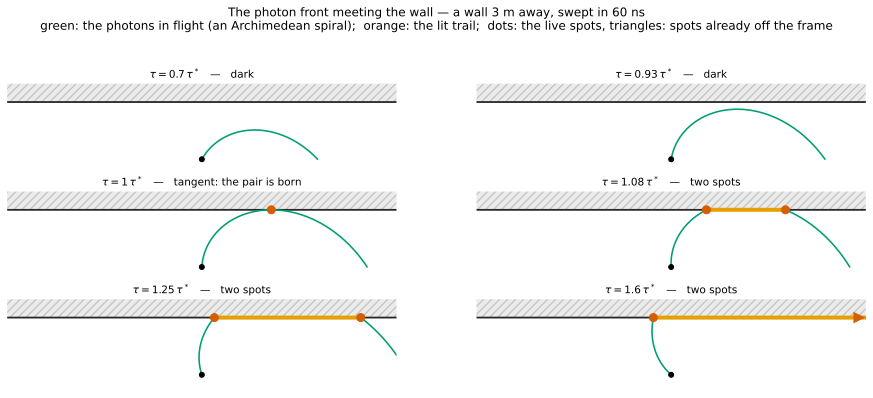

In [28]:
def drawSpiralGrid(spiral, fractions=(0.70, 0.93, 1.0, 1.08, 1.25, 1.60),
                   xSpan=3.4, yLo=-0.28, yHi=1.32, figsize=(13.2, 5.6), title=None):
    '''Six moments of the photon front meeting the wall. Lengths in units of D.'''
    S = spiral.system
    fig, axes = plt.subplots(3, 2, figsize=figsize)

    for ax, fraction in zip(axes.ravel(), fractions):
        when = fraction*spiral.tauStar
        ax.plot([-xSpan, xSpan], [1, 1], color='0.15', lw=1.8, zorder=3)
        ax.fill_between([-xSpan, xSpan], 1, yHi, color='0.92', hatch='///',
                        edgecolor='0.72', lw=0, zorder=1)

        lit = spiral.trail(when)/S.D
        if lit.size:
            ax.plot([lit.min(), lit.max()], [1, 1], color='#E69F00', lw=4.0,
                    solid_capstyle='butt', zorder=4)

        fx, fy, landed = spiral.front(when)
        # blank out the landed photons so the spiral is only what is still flying; the gap
        # they leave is contiguous, so NaN breaks the line in exactly the right two places
        inFlight = np.where(landed, np.nan, 1.0)
        ax.plot(fx/S.D*inFlight, fy/S.D*inFlight, color='#009E73', lw=1.6, zorder=5)
        ax.plot([0], [0], 'o', color='k', ms=5, zorder=7)

        landing = spiral.spots(when)
        for s in landing:
            position = spiral.arrival.x(s)/S.D
            if abs(position) <= xSpan - 0.08:
                ax.plot([position], [1], 'o', color='#D55E00', ms=8, zorder=8)
            else:                       # already off the frame, and still going
                ax.plot([np.sign(position)*(xSpan - 0.12)], [1], zorder=8, ms=10,
                        marker='>' if position > 0 else '<', color='#D55E00')

        count = {0: 'dark', 1: 'tangent: the pair is born', 2: 'two spots'}[len(landing)]
        ax.set_title(rf'$\tau = {fraction:g}\,\tau^*$   —   {count}', fontsize=10.5)
        ax.set_xlim(-xSpan, xSpan); ax.set_ylim(yLo, yHi)
        ax.set_aspect('equal'); ax.axis('off')

        if fraction == 1.0:      # the tangency: check it rather than just claiming it
            gap = np.min(np.abs(fy - S.D))
            assert gap < 2e-6*S.D, gap
            assert abs(spiral.arrival.x(spiral.tStar) - spiral.arrival.x(landing[0])) < 1e-9*S.D

    fig.suptitle(title or (f'The photon front meeting the wall — {S.label}\n'
                           r'green: the photons in flight (an Archimedean spiral);  orange: the lit '
                           r'trail;  dots: the live spots, triangles: spots already off the frame'),
                 fontsize=12)
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    return fig

display(asSVG(drawSpiralGrid(desk.spiral)))

Read in order: the spiral sweeps outwards at $c$, misses the wall entirely, then **touches** it at
$\tau^*$ — and from that moment the two intersections run apart along the wall and never come back.
The first light lands at $x^* = 1.214\,D$, not at $x = +\infty$ where the beam was first aimed,
because that part of the wall is infinitely far away and its light is still in flight.

The backward spot dies on the Moon because the sphere runs out of near side. A plane never runs out.

## 8. The regime map

Everything is a function of $\mu = kD\omega/c$, so the whole family of walls, sweep rates and
observers is one curve family. The threshold from §3.2 is visible in it.

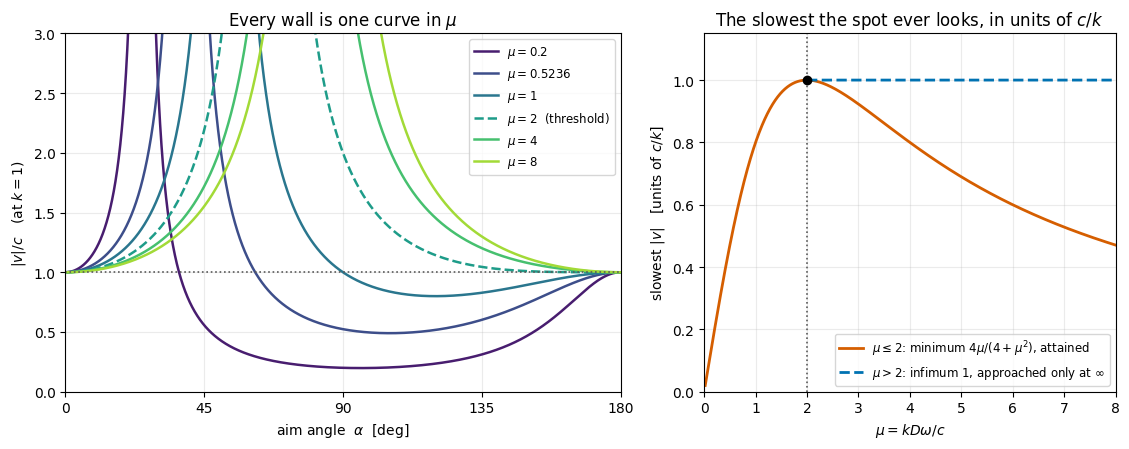

In [29]:
def plotRegimes(muValues=(0.2, 0.5236, 1.0, 2.0, 4.0, 8.0), figsize=(11.4, 4.6)):
    speedIn = lambdify((alpha, mu), (pointSpeedReduced/c).subs(k, 1), 'numpy')
    a = np.linspace(0, np.pi, 6001)[1:-1]

    fig, (axV, axM) = plt.subplots(1, 2, figsize=figsize,
                                   gridspec_kw={'width_ratios': [1.35, 1]})
    colours = plt.cm.viridis(np.linspace(0.08, 0.86, len(muValues)))
    for muValue, colour in zip(muValues, colours):
        with np.errstate(all='ignore'):
            speed = np.abs(speedIn(a, muValue))
        speed[np.abs(np.sin(a)**2 - muValue*np.cos(a)) < 1e-9] = np.nan     # mask the fold
        axV.plot(np.degrees(a), speed, color=colour, lw=1.8,
                 label=rf'$\mu = {muValue:g}$' + ('  (threshold)' if muValue == 2 else ''),
                 ls='--' if muValue == 2 else '-')
    axV.axhline(1, ls=':', lw=1.2, color='0.35')
    axV.set_xlim(0, 180); axV.set_ylim(0, 3)
    axV.set_xticks([0, 45, 90, 135, 180])
    axV.set_xlabel(r'aim angle  $\alpha$  [deg]')
    axV.set_ylabel(r'$|v|/c$   (at $k = 1$)')
    axV.set_title(r'Every wall is one curve in $\mu$')
    axV.grid(alpha=0.25); axV.legend(fontsize=8.5)

    m = np.linspace(0.02, 8, 2000)
    axM.plot(m, 4*m/(4 + m**2), color='#D55E00', lw=2.0,
             label=r'$\mu \leq 2$: minimum $4\mu/(4+\mu^2)$, attained')
    axM.plot(m[m > 2], np.ones_like(m[m > 2]), color='#0072B2', lw=2.0, ls='--',
             label=r'$\mu > 2$: infimum $1$, approached only at $\infty$')
    axM.axvline(2, ls=':', lw=1.2, color='0.35')
    axM.plot([2], [1], 'o', color='k', ms=6, zorder=5)
    axM.set_xlim(0, 8); axM.set_ylim(0, 1.15)
    axM.set_xlabel(r'$\mu = k D \omega / c$')
    axM.set_ylabel(r'slowest $|v|$   [units of $c/k$]')
    axM.set_title(r'The slowest the spot ever looks, in units of $c/k$')
    axM.grid(alpha=0.25); axM.legend(fontsize=8.5, loc='lower right')
    fig.tight_layout()
    return fig

plotRegimes()
plt.show()

- **$\mu \le 2$** — the spot decelerates to a genuine minimum $4c\mu/(k(4+\mu^2))$ and speeds up again.
- **$\mu > 2$** — no minimum: $|v|$ slides monotonically towards $c/k$ and only reaches it at infinity.
- At $k = 1$ the minimum touches exactly $c$ at $\mu = 2$ and is below it everywhere else, because
  $1 - 4\mu/(4+\mu^2) = (\mu-2)^2/(\mu^2+4)$ is a square. A sweep at $D\omega = 2c$ is the one that
  grazes the light barrier without crossing.

### 8.1 The scaling symmetry, and the Moon

Since only $\mu = k\nu$ enters, the *shape* of everything depends on $k$ and $\nu$ only through their
product. So an observer at the laser watching a wall swept at $\nu$ sees exactly the geometry that
light landing on a wall swept at $2\nu$ would have — with every speed halved. Changing observer is
equivalent to changing the sweep rate.

In [30]:
slow = WallSystem('half-rate wall', distance=desk.D, speedOfLight=desk.c,
                  lengthUnit=desk.lengthUnit, timeUnit=desk.timeUnit, sweepRate=desk.omega/2)
lhs, rhs = WallCase(desk, 2, 'observed'), WallCase(desk, 1, 'at the wall')
mirror   = WallCase(slow, 2, 'observed at half rate')

assert abs(lhs.mu - rhs.mu) > 0.4                                    # genuinely different cases
assert abs(mirror.mu - rhs.mu) < 1e-12                               # ... but mu matches here
assert abs(mirror.alphaStar - rhs.alphaStar) < 1e-12
assert abs(mirror.alphaSlow - rhs.alphaSlow) < 1e-12
assert abs(mirror.vSlow/mirror.system.c - rhs.vSlow/rhs.system.c/2) < 1e-12
print(f'k=2 at nu={slow.nu:.6f} and k=1 at nu={desk.nu:.6f} share mu={rhs.mu:.6f}:')
print(f'   alpha* {np.degrees(mirror.alphaStar):.6f} = {np.degrees(rhs.alphaStar):.6f} deg,'
      f'   slowest {mirror.vSlow/slow.c:.6f} c = half of {rhs.vSlow/desk.c:.6f} c')

k=2 at nu=0.261799 and k=1 at nu=0.523599 share mu=0.523599:
   alpha* 39.474989 = 39.474989 deg,   slowest 0.245007 c = half of 0.490014 c


Now the Moon. `MoonSweep.ipynb` found the spot at its sub-Earth point running at $-1.153076\,c$, the
same for both $k$ because $dL/dt = 0$ there. The wall on the Moon's tangent plane, swept at the same
rate, must reproduce that number exactly — near the middle of the sweep the sphere and its tangent
plane are the same surface, and both notebooks are asking the same question of it.

In [31]:
moonCases = [WallCase(moonWall, 1, 'Arrival at the wall'),
             WallCase(moonWall, 2, 'Observed back at the laser')]
comparisonTable(moonCases, moonWall)

MOONSWEEP_SUB_EARTH = -1.153076        # MoonSweep.ipynb, spot speed at the sub-Earth point, both k
for case in moonCases:
    assert abs(case.v(moonWall.T/2)/moonWall.c - MOONSWEEP_SUB_EARTH) < 5e-7
print(f'\nclosest-approach speed matches MoonSweep.ipynb\'s sub-Earth {MOONSWEEP_SUB_EARTH} c '
      f'for k = 1 and k = 2')

a wall on the Moon tangent plane, at the MoonSweep rate   (nu = 1.153076)
                                             k=1                k=2
----------------------------------------------------------------------
mu = k*D*omega/c                        1.153076           2.306151
pair creation  alpha* [deg]              54.7071            68.0856
pair creation  t* [s]                    1.05098            1.30800
pair creation  t*/T                       0.3039             0.3783
pair creation  tau* [s]                 2.605988           4.044122
pair creation  x*/D                       0.7079             0.4023
speed at the grazing ends [c]             1.0000             0.5000
slowest spot speed [c]                  0.865415                  —
slowest at alpha [deg]                  125.2074                  —
speed at closest approach [c]          -1.153076          -1.153076
number of |v| = c crossings                    1                  2

closest-approach speed matches MoonSwe

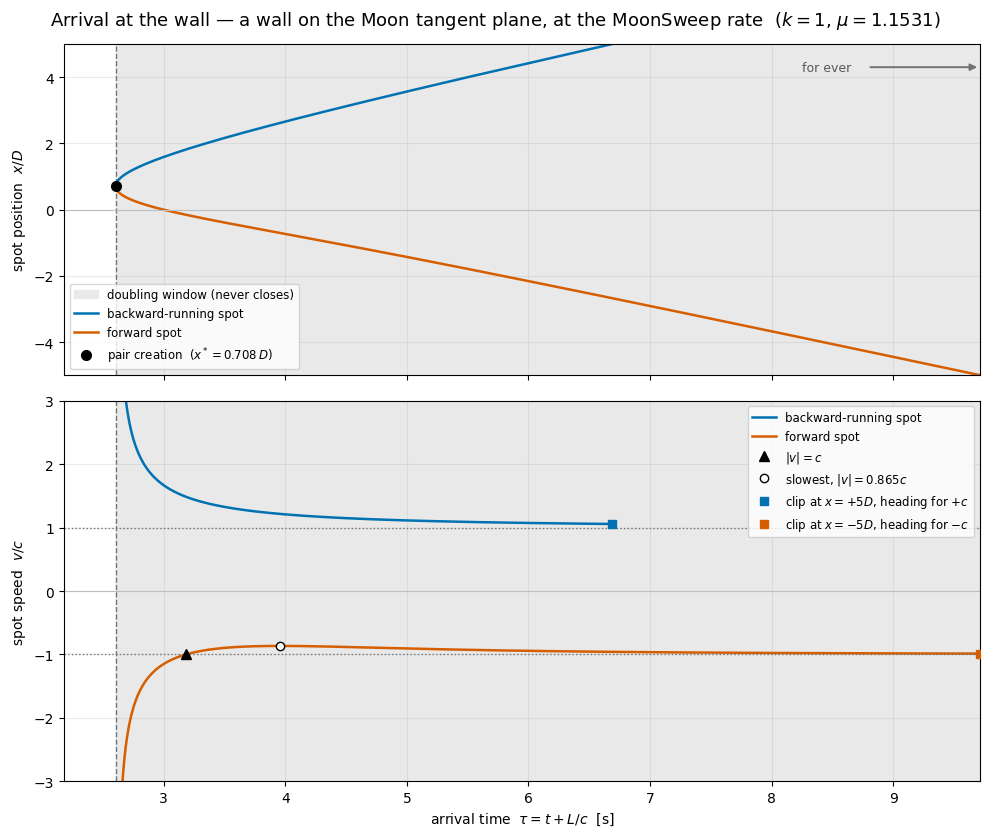

In [32]:
plotCase(moonCases[0])
plt.show()

The two notebooks agree where they must and part company where they should. The sphere's near side
runs out at its limb, which closes the doubling window after 2.64 ms; the plane's does not, so the
window stays open for ever. Away from closest approach the tangent plane is nowhere near the Moon,
and the numbers diverge accordingly — $\alpha^* = 54.71°$ from the axis here against the Moon's
$\beta^* = 40.73°$ of latitude, measured on a different surface.

## 9. Cross-check at 30–60 digits

The closed forms above came out of SymPy, and the plots came out of `lambdify` and NumPy. Neither
route is independent of the other. `mpmath` ships with SymPy, so re-deriving the same quantities in
plain high-precision arithmetic costs no dependency and does confirm the pipeline.

In [33]:
from mpmath import mp, mpf, findroot, cos as mcos, sin as msin, acos as macos, sqrt as msqrt

def highPrecision(system, legs, digits=50):
    '''t*, tau*, alpha_slow and |v|min from scratch, at `digits` significant digits.'''
    mp.dps = digits
    Dm, cm, wm = mpf(repr(system.D)), mpf(repr(system.c)), mpf(repr(system.omega))
    muM = legs*Dm*wm/cm

    arrivalRate = lambda a: 1 - muM*mcos(a)/msin(a)**2            # dtau/dt as a function of alpha
    aStar = findroot(arrivalRate, mpf('1.0'), tol=mpf(10)**(-2*digits))
    tStar = aStar/wm
    tauStar = tStar + legs*(Dm/msin(aStar))/cm
    speed = lambda a: -cm*muM/(legs*(msin(a)**2 - muM*mcos(a)))
    out = {'alphaStar': aStar, 'tStar': tStar, 'tauStar': tauStar}
    if muM <= 2:
        aSlow = macos(-muM/2)
        out['alphaSlow'], out['vSlow'] = aSlow, abs(speed(aSlow))
    # Section 3.1's closed form, checked here against the root found numerically. Both are
    # evaluated while mp.dps is still `digits`, so the comparison is a real high-precision one.
    out['foldDeviation'] = abs((msqrt(muM**2 + 4) - muM)/2 - mcos(aStar))
    return out

for case in (atWall, seenAtLaser, moonCases[0]):
    ref = highPrecision(case.system, case.k)
    mp.dps = 30
    print(f'{case.system.lengthUnit}/{case.system.timeUnit}, k = {case.k}:')
    print(f'   alpha*  mpmath {mp.nstr(ref["alphaStar"], 25)}   float64 rel dev '
          f'{abs(float(ref["alphaStar"]) - case.alphaStar)/case.alphaStar:.2e}')
    print(f'   tau*    mpmath {mp.nstr(ref["tauStar"], 25)}   float64 rel dev '
          f'{abs(float(ref["tauStar"]) - case.tauStar)/case.tauStar:.2e}')
    assert abs(float(ref['alphaStar']) - case.alphaStar) < 1e-14*case.alphaStar
    assert abs(float(ref['tauStar'])   - case.tauStar)   < 1e-14*case.tauStar
    assert ref['foldDeviation'] < mpf(10)**(-40), ref['foldDeviation']
    if case.vSlow is not None:
        print(f'   |v|min  mpmath {mp.nstr(ref["vSlow"]/mpf(repr(case.system.c)), 25)} c'
              f'   float64 rel dev {abs(float(ref["vSlow"]) - case.vSlow)/case.vSlow:.2e}')
        assert abs(float(ref['vSlow']) - case.vSlow) < 1e-14*case.vSlow
print(f'\nclosed form vs numerical root for cos(alpha*): agree to better than 1e-40 in every case')

m/ns, k = 1:
   alpha*  mpmath 0.6889685289438918777422482   float64 rel dev 3.22e-16
   tau*    mpmath 28.88799765956616830038917   float64 rel dev 0.00e+00
   |v|min  mpmath 0.4900137618448393202461367 c   float64 rel dev 1.89e-16
m/ns, k = 2:
   alpha*  mpmath 0.9207964980553877892977676   float64 rel dev 0.00e+00
   tau*    mpmath 42.7088977685411884089527   float64 rel dev 0.00e+00
   |v|min  mpmath 0.410937834926936961126875 c   float64 rel dev 0.00e+00
km/s, k = 1:
   alpha*  mpmath 0.9548187305741606529953866   float64 rel dev 1.16e-16
   tau*    mpmath 2.60598795307799172729495   float64 rel dev 1.53e-15
   |v|min  mpmath 0.8654151897909045601033886 c   float64 rel dev 1.12e-16

closed form vs numerical root for cos(alpha*): agree to better than 1e-40 in every case


## 10. What the notebook shows

A laser pointer swept across a flat wall reproduces every relativistic illumination effect the Moon
showed, and in closed form:

- **The spot is created as a pair.** At $\tau^*$ the first light lands at one point with infinite
  apparent speed, and splits into two spots running in opposite directions. Before that the wall is
  dark, even though the laser has been on since $t = 0$.
- **The pair never annihilates.** On a sphere the backward spot dies at the limb; on an infinite
  plane it runs to $x = +\infty$, so two spots exist for every arrival time after $\tau^*$.
- **Both spots approach exactly $c/k$** — $c$ at the wall, $c/2$ for an observer at the laser —
  independent of distance and sweep rate. This is grazing incidence, the same mechanism as the Moon's
  limb, and here `limit()` proves it for symbolic $k$ in a fraction of a second.
- **The speed at closest approach is the same for every observer**, because $dL/dt = 0$ there and the
  leg count cancels. Everywhere else, apparent speed depends on where you stand.
- **One number governs everything**: $\mu = kD\omega/c$, with a threshold at $\mu = 2$ separating a
  spot that dips subluminal from one that never does. Changing observer is the same as changing the
  sweep rate.
- **The photon front is an exact Archimedean spiral**, and its tangency to the wall is the fold. The
  doubling is not an artefact of the algebra: it is what a curve does when it stops missing a surface.

None of this is information travelling faster than light. The spot is a projection — like the
intersection point of a pair of scissors — and no photon overtakes another. What is superluminal is
the *appearance*, assembled by an observer out of light that left at different times.